# 30 — Conservation Prioritisation: Circuit-Theory Corridors

Identify ecological corridors using circuit theory applied to the GNN-predicted
habitat suitability graph. Current flow through the landscape patch network
reveals which patches are critical for connectivity between habitat fragments.

**Approach**:
1. Use the species' own GNN suitability to define core habitat and conductance
2. Build a conductance matrix from the patch graph (conductance = suitability)
3. Solve for current flow between isolated core clusters
4. High-current patches = corridors (pinch points for connectivity)

### Setup

In [2]:
import config
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import matplotlib.pyplot as plt
from data_utils import load_species_patches, load_patch_data

# Load graph
with open('landscape_graph.pkl', 'rb') as f:
    G = pickle.load(f)

patch_features, patch_counts, feature_names = load_patch_data()
n_patches = G.number_of_nodes()
print(f'Graph: {n_patches:,} nodes, {G.number_of_edges():,} edges')

# Species-to-patch mapping
species_patches, species_counts = load_species_patches(config)

Patches: 166,464, features: 12
Graph: 166,464 nodes, 465,833 edges
Coordinate uncertainty filter (<=1000m): 22,723,973 -> 3,143,834 records (13.8% retained)
GBIF records: 3,143,834
Species with >= 20 presence patches: 2,696


### Load GNN suitability predictions

In [3]:
# Load suitability scores from the production training job
scores_npz = np.load('gnn_training_output/suitability_scores.npz')

def get_suitability(species_name):
    """Get suitability array for a species (handles name format)."""
    key = species_name.replace(' ', '_')
    if key in scores_npz:
        return scores_npz[key]
    return None

# Quick check
test = get_suitability('Cypripedium calceolus')
print(f'Loaded suitability for {len(scores_npz.files):,} species')
print(f'Cypripedium calceolus: mean={test.mean():.3f}, max={test.max():.3f}')

Loaded suitability for 2,696 species
Cypripedium calceolus: mean=0.156, max=0.899


### Circuit-theory corridor computation

Treat the patch graph as an electrical network:
- **Conductance** between adjacent patches = mean suitability (high suitability = easy to traverse)
- **Sources** = one core cluster (inject current)
- **Grounds** = another core cluster (extract current)
- **Current flow** through each patch reveals its importance for connectivity

Patches with high current are bottlenecks — if they're lost, connectivity between
habitat fragments breaks down. These are the true corridors.

In [4]:
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

def compute_current_flow(G, suitability, core_threshold=0.3,
                         core_patches=None,
                         n_pairs=5, min_component_size=5):
    """
    Compute current flow through the patch network using circuit theory.

    Parameters
    ----------
    G : nx.Graph
        Landscape patch graph.
    suitability : np.ndarray (n_patches,)
        Per-patch suitability from the GNN (used as conductance).
    core_threshold : float
        Suitability above which a patch is 'core habitat' (ignored if core_patches given).
    core_patches : set[int] | None
        If provided, use these as core patches (e.g., actual observations).
    n_pairs : int
        Number of source-ground pairs to solve (top components).
    min_component_size : int
        Minimum patches for a core component to be considered.

    Returns
    -------
    current : np.ndarray (n_patches,)
        Cumulative current flow through each patch.
    cores : set[int]
        Core habitat patches.
    components : list[set]
        Core components used as sources/grounds.
    """
    n = G.number_of_nodes()
    nodes = sorted(G.nodes())
    node_to_idx = {nd: i for i, nd in enumerate(nodes)}

    # Build conductance-based Laplacian (sparse)
    print('  Building conductance matrix...')
    L = lil_matrix((n, n), dtype=np.float64)
    for u, v in G.edges():
        i, j = node_to_idx[u], node_to_idx[v]
        conductance = max(1e-4, (suitability[u] + suitability[v]) / 2)
        L[i, j] -= conductance
        L[j, i] -= conductance
        L[i, i] += conductance
        L[j, j] += conductance
    L = csr_matrix(L)

    # Identify core components
    if core_patches is not None:
        cores = set(core_patches)
    else:
        cores = set(np.where(suitability >= core_threshold)[0])
    core_subgraph = G.subgraph(cores)
    components = [c for c in nx.connected_components(core_subgraph)
                  if len(c) >= min_component_size]
    components.sort(key=len, reverse=True)
    print(f'  Core patches: {len(cores):,} (threshold={core_threshold})')
    print(f'  Core components (>= {min_component_size}): {len(components)}')

    if len(components) < 2:
        print('  Not enough components for circuit analysis.')
        return np.zeros(len(suitability)), cores, components

    # Solve for current flow between top component pairs
    current = np.zeros(n, dtype=np.float64)
    n_solve = min(len(components), n_pairs)

    for pair_i in range(n_solve - 1):
        src_component = components[pair_i]
        gnd_component = components[pair_i + 1]

        # Set up RHS: inject current at source, extract at ground
        rhs = np.zeros(n)
        src_indices = [node_to_idx[nd] for nd in src_component]
        gnd_indices = [node_to_idx[nd] for nd in gnd_component]

        for idx in src_indices:
            rhs[idx] = 1.0 / len(src_indices)
        for idx in gnd_indices:
            rhs[idx] = -1.0 / len(gnd_indices)

        # Pin one ground node voltage to 0 (make system solvable)
        pin = gnd_indices[0]
        L_solve = L.copy().tolil()
        L_solve[pin, :] = 0
        L_solve[pin, pin] = 1
        rhs[pin] = 0

        # Solve for voltages
        voltages = spsolve(csr_matrix(L_solve), rhs)

        # Compute current through each node
        node_current = np.zeros(n)
        for u, v in G.edges():
            i, j = node_to_idx[u], node_to_idx[v]
            conductance = max(1e-4, (suitability[u] + suitability[v]) / 2)
            edge_current = abs(conductance * (voltages[i] - voltages[j]))
            node_current[i] += edge_current
            node_current[j] += edge_current

        current += node_current
        print(f'  Pair {pair_i+1}: {len(src_component)} nodes <-> {len(gnd_component)} nodes')

    # Map back to patch IDs
    current_by_patch = np.zeros(len(suitability))
    for nd, idx in node_to_idx.items():
        current_by_patch[nd] = current[idx]

    return current_by_patch, cores, components

print('Circuit theory corridor function defined.')

Circuit theory corridor function defined.


### Run circuit analysis for Cypripedium calceolus

In [5]:
import time

# Use the species' own suitability for conductance
cyp_suit = get_suitability('Cypripedium calceolus')

# Use actual observation patches as cores (known populations)
cyp_presence = species_patches.get('Cypripedium calceolus', set())
print(f'Cypripedium calceolus: {len(cyp_presence)} presence patches')

print('\nComputing current flow between known populations...')
t0 = time.time()
current_flow, cores, components = compute_current_flow(
    G, cyp_suit,
    core_patches=cyp_presence,  # use actual observations as cores
    n_pairs=6, min_component_size=3
)
dt = time.time() - t0
print(f'\nDone in {dt:.1f}s')
print(f'Max current: {current_flow.max():.4f}')
print(f'Patches with current > 0.001: {(current_flow > 0.001).sum():,}')

Cypripedium calceolus: 369 presence patches

Computing current flow between known populations...
  Building conductance matrix...
  Core patches: 369 (threshold=0.3)
  Core components (>= 3): 17
  Pair 1: 14 nodes <-> 7 nodes
  Pair 2: 7 nodes <-> 6 nodes
  Pair 3: 6 nodes <-> 6 nodes
  Pair 4: 6 nodes <-> 6 nodes
  Pair 5: 6 nodes <-> 5 nodes

Done in 31.4s
Max current: 3.6698
Patches with current > 0.001: 86,353


### Visualise — Cypripedium calceolus current flow map

Current flow: p75=0.06240, p99=0.79398, max=0.79398
Cypripedium calceolus observations in ROI: 279


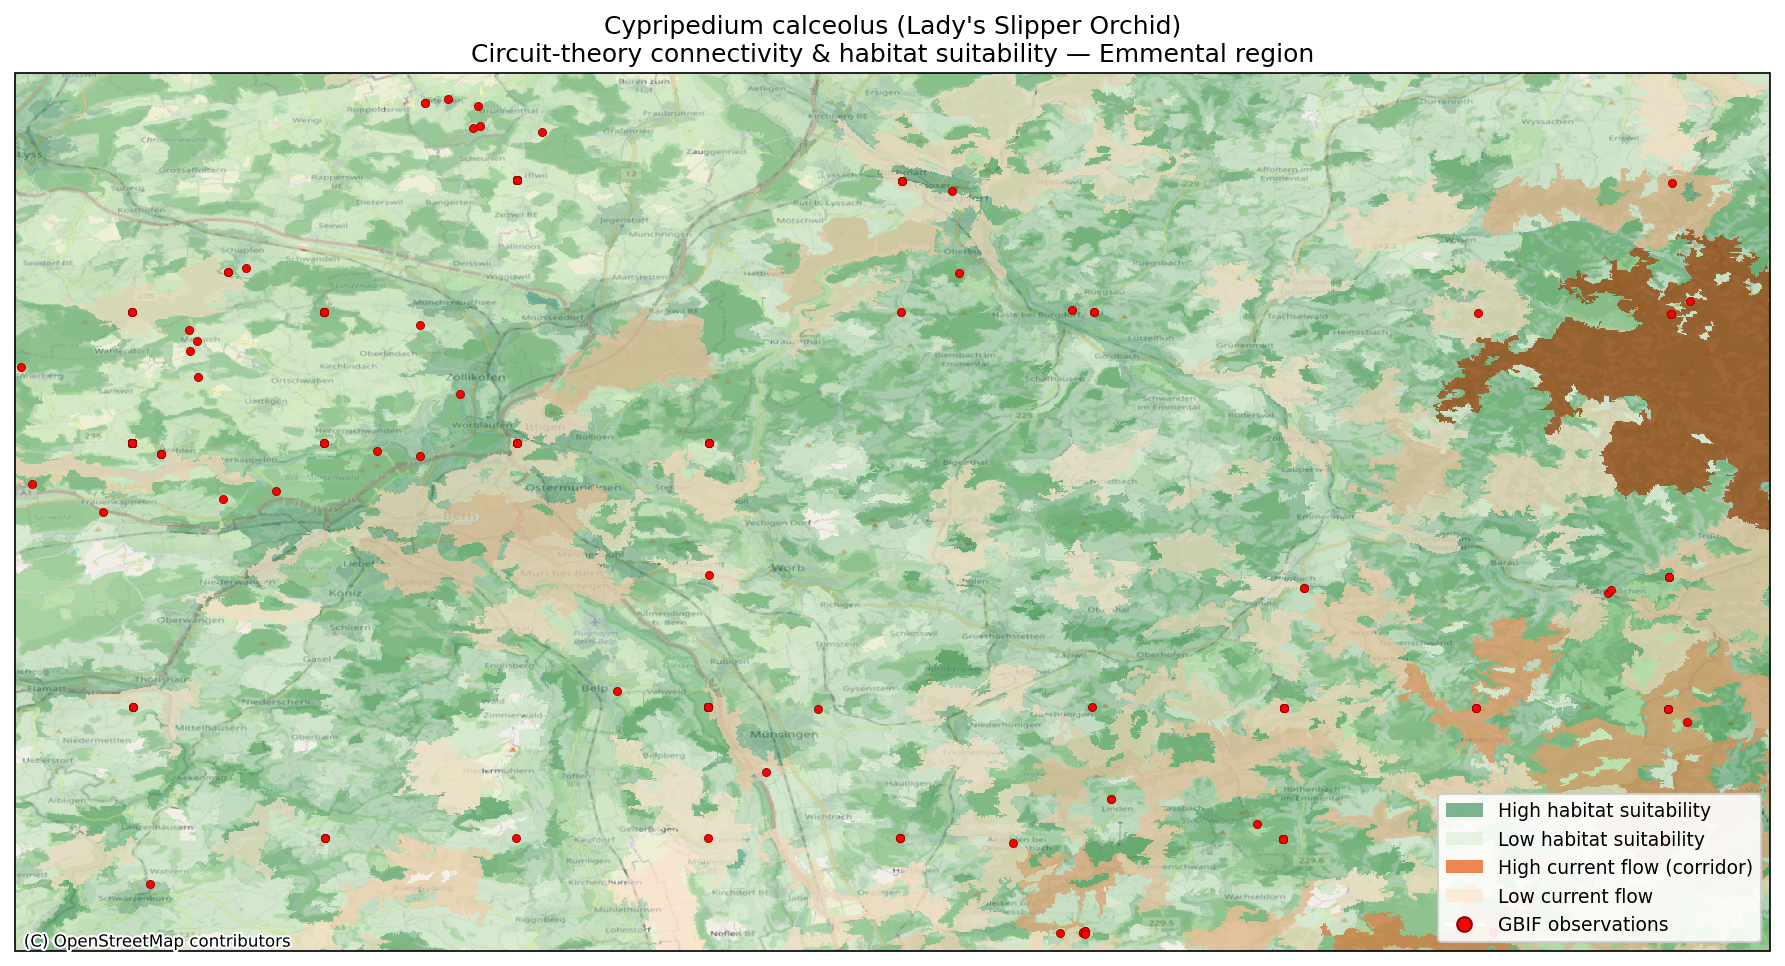

In [6]:
import contextily as cx
import cartopy.crs as ccrs
import numpy.ma as ma
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from s3_utils import load_zarr

# ROI: Emmental / northern Bernese Oberland
roi = {'lon_min': 7.3, 'lon_max': 7.9, 'lat_min': 46.8, 'lat_max': 47.1}

# Load patch labels and clip to ROI
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
label_roi = patch_labels_da.sel(
    y=slice(roi['lat_max'], roi['lat_min']),
    x=slice(roi['lon_min'], roi['lon_max']),
)
labels_arr = label_roi.values
valid = labels_arr >= 0

# Map suitability and current to ROI pixels
suit_roi = np.zeros_like(labels_arr, dtype=np.float32)
suit_roi[valid] = cyp_suit[labels_arr[valid]]

current_roi = np.zeros_like(labels_arr, dtype=np.float32)
current_roi[valid] = current_flow[labels_arr[valid]]

# Mask: show suitability where > 0.1
suit_masked = ma.masked_where((~valid) | (suit_roi < 0.1), suit_roi)

# Normalise current for display
# Use percentile-based thresholding so only top corridor patches are shown
current_valid = current_roi[valid & (current_roi > 0)]
current_p75 = np.percentile(current_valid, 75)  # only show top 25% of flow
current_p99 = np.percentile(current_valid, 99)  # cap display at p99
print(f'Current flow: p75={current_p75:.5f}, p99={current_p99:.5f}, max={current_valid.max():.5f}')

# Mask out pixels below p75 threshold — these are NOT corridors
current_masked = ma.masked_where(
    (~valid) | (current_roi < current_p75), current_roi
)

# Colormaps
green_cmap = LinearSegmentedColormap.from_list('greens', ['#c7e9c0', '#006d2c'])
orange_cmap = LinearSegmentedColormap.from_list('currents', ['#fee6ce', '#e6550d', '#a63603'])

# Plot
fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()},
                       dpi=150)

ax.set_extent([roi['lon_min'], roi['lon_max'],
               roi['lat_min'], roi['lat_max']])

# Basemap
cx.add_basemap(ax, crs=ccrs.PlateCarree(),
               source=cx.providers.OpenStreetMap.Mapnik,
               zoom=12)

extent = [roi['lon_min'], roi['lon_max'], roi['lat_min'], roi['lat_max']]

# Layer 1: Suitability gradient (increased alpha for visibility)
ax.imshow(suit_masked, cmap=green_cmap, vmin=0.1, vmax=0.8, alpha=0.55,
          extent=extent, origin='upper', interpolation='nearest',
          transform=ccrs.PlateCarree())

# Layer 2: Current flow — only top corridor patches, clipped at p99
ax.imshow(current_masked, cmap=orange_cmap, alpha=0.65,
          vmin=current_p75, vmax=current_p99,
          extent=extent, origin='upper', interpolation='nearest',
          transform=ccrs.PlateCarree())

# Layer 3: GBIF observations
gbif = pd.read_parquet(config.GBIF_PARQUET, storage_options={'anon': False})
cyp_obs = gbif[gbif['species'] == 'Cypripedium calceolus']
cyp_roi = cyp_obs[
    (cyp_obs['decimallongitude'] >= roi['lon_min']) &
    (cyp_obs['decimallongitude'] <= roi['lon_max']) &
    (cyp_obs['decimallatitude'] >= roi['lat_min']) &
    (cyp_obs['decimallatitude'] <= roi['lat_max'])
]
ax.scatter(cyp_roi['decimallongitude'], cyp_roi['decimallatitude'],
           s=15, c='red', marker='o', edgecolors='darkred', linewidths=0.4,
           transform=ccrs.PlateCarree(), zorder=5)
print(f'Cypripedium calceolus observations in ROI: {len(cyp_roi)}')

# Legend
legend_elements = [
    Patch(facecolor='#006d2c', alpha=0.5, label='High habitat suitability'),
    Patch(facecolor='#c7e9c0', alpha=0.4, label='Low habitat suitability'),
    Patch(facecolor='#e6550d', alpha=0.7, label='High current flow (corridor)'),
    Patch(facecolor='#fee6ce', alpha=0.7, label='Low current flow'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
               markeredgecolor='darkred', markersize=7, label='GBIF observations'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          framealpha=0.9)

ax.set_title('Cypripedium calceolus (Lady\'s Slipper Orchid)\n'
             'Circuit-theory connectivity & habitat suitability — Emmental region',
             fontsize=12)
plt.tight_layout()
plt.show()

### Summary statistics

In [7]:
# Quantify corridor importance
high_current_threshold = np.percentile(current_flow[current_flow > 0], 90)
corridor_patches = set(np.where(current_flow >= high_current_threshold)[0])

print(f'Core habitat patches (observed populations): {len(cores):,}')
print(f'Core components: {len(components)}')
print(f'High-current corridor patches (top 10%): {len(corridor_patches):,}')
print(f'Total priority area: {len(cores | corridor_patches):,} patches '
      f'({len(cores | corridor_patches) / n_patches * 100:.1f}% of landscape)')

# Validate: do observations cluster on high-current patches?
obs_patches = species_patches.get('Cypripedium calceolus', set())
obs_on_corridor = obs_patches & corridor_patches
obs_on_core = obs_patches & cores
print(f'\nValidation:')
print(f'  Observation patches on core: {len(obs_on_core)} / {len(obs_patches)} '
      f'({len(obs_on_core)/len(obs_patches)*100:.1f}%)')
print(f'  Observation patches on corridor: {len(obs_on_corridor)} / {len(obs_patches)} '
      f'({len(obs_on_corridor)/len(obs_patches)*100:.1f}%)')
print(f'  Mean current at observation patches: {current_flow[list(obs_patches)].mean():.4f}')
print(f'  Mean current at random patches: {current_flow.mean():.4f}')
print(f'  Ratio: {current_flow[list(obs_patches)].mean() / max(current_flow.mean(), 1e-8):.1f}x')

Core habitat patches (observed populations): 369
Core components: 17
High-current corridor patches (top 10%): 16,193
Total priority area: 16,335 patches (9.8% of landscape)

Validation:
  Observation patches on core: 369 / 369 (100.0%)
  Observation patches on corridor: 227 / 369 (61.5%)
  Mean current at observation patches: 0.1734
  Mean current at random patches: 0.0109
  Ratio: 16.0x


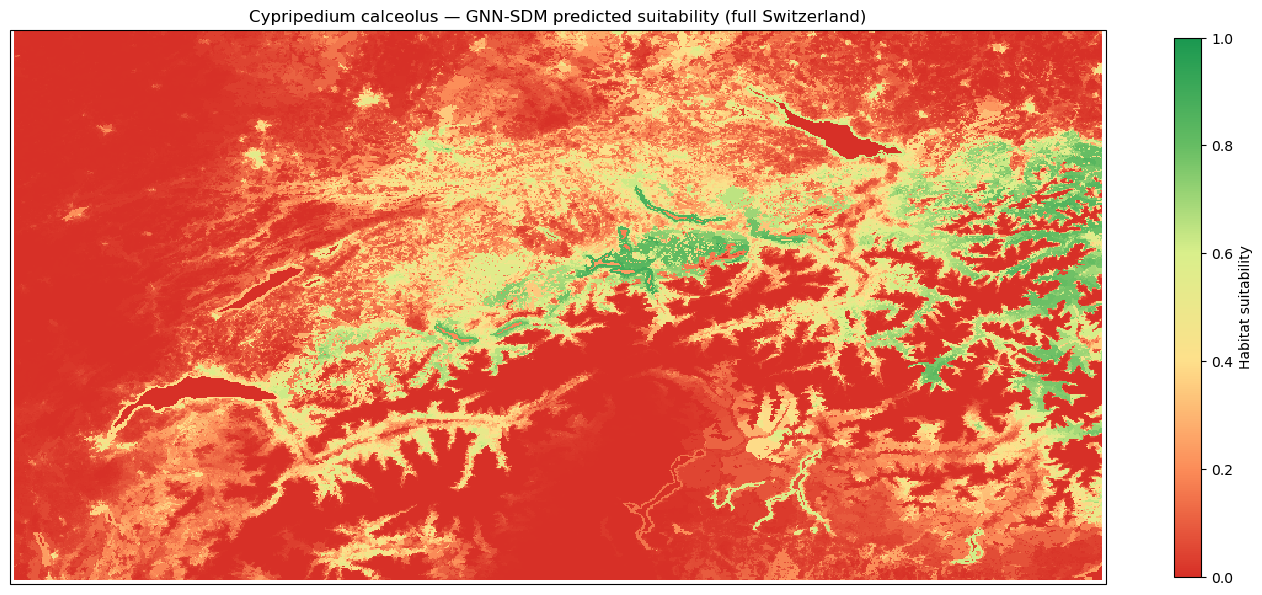

Suitability range: [0.000, 0.899]
Mean: 0.166, Median: 0.070
Patches > 0.3: 33,449 / 166,464 (20.1%)
Patches > 0.5: 12,088 / 166,464 (7.3%)


: 

In [ ]:
import cartopy.crs as ccrs
import numpy.ma as ma
from matplotlib.colors import LinearSegmentedColormap
from s3_utils import load_zarr

# Load patch labels (full Switzerland)
patch_labels_da = load_zarr(
    config.S3_PROCESSED + '/patches/patch_labels_30m.zarr',
    name='patch_label',
)
labels = patch_labels_da.values
valid = labels >= 0

# Map Cypripedium suitability to raster
suit_map = np.zeros_like(labels, dtype=np.float32)
suit_map[valid] = cyp_suit[labels[valid]]
suit_masked = ma.masked_where(~valid, suit_map)

# Downsample for display
step = 20
from geo_utils import BOUNDS
extent = [BOUNDS['lon_min'], BOUNDS['lon_max'],
          BOUNDS['lat_min'], BOUNDS['lat_max']]

# Diverging colormap: red (unsuitable) -> white -> green (suitable)
cmap = LinearSegmentedColormap.from_list(
    'suit', ['#d73027', '#fc8d59', '#fee08b', '#d9ef8b', '#66bd63', '#1a9850']
)

fig, ax = plt.subplots(figsize=(14, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.imshow(suit_masked[::step, ::step], cmap=cmap, vmin=0, vmax=1,
               extent=extent, origin='upper', interpolation='nearest',
               transform=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)
plt.colorbar(im, ax=ax, label='Habitat suitability', shrink=0.7)
ax.set_title('Cypripedium calceolus — GNN-SDM predicted suitability (full Switzerland)')
plt.tight_layout()
plt.show()

# Stats
print(f'Suitability range: [{suit_map[valid].min():.3f}, {suit_map[valid].max():.3f}]')
print(f'Mean: {suit_map[valid].mean():.3f}, Median: {np.median(suit_map[valid]):.3f}')
print(f'Patches > 0.3: {(cyp_suit > 0.3).sum():,} / {n_patches:,} ({(cyp_suit > 0.3).sum()/n_patches*100:.1f}%)')
print(f'Patches > 0.5: {(cyp_suit > 0.5).sum():,} / {n_patches:,} ({(cyp_suit > 0.5).sum()/n_patches*100:.1f}%)')
